# 03 · Symplectic ODE-Net / Port-Hamiltonian NN with control (Zhong, Dey & Chakraborty, 2020)

Papers:
- `papers/01_Fundamentos_y_Arquitecturas_Base/Zhong et al 2020 - Symplectic
  ODE-Net.pdf` — arXiv:1909.12077, ICLR 2020.
- Conceptually the same family as section 2 of the state-of-the-art document
  ("Port-Hamiltonian Neural Networks"), which generalizes this to dissipative and
  fully port-Hamiltonian systems.

**What changes relative to notebooks `01`/`02`.** HNN and LNN both learn
*autonomous* (uncontrolled) dynamics. Many real systems of interest (robots,
actuated pendulums, circuits) have an **external input** `u` that the model must
also account for. SymODEN's core idea (paper Eq. 2) is to keep the Hamiltonian
structure but add a control term:

$$\dot q = \frac{\partial H_\theta}{\partial p}, \qquad
  \dot p = -\frac{\partial H_\theta}{\partial q} + g(q)\, u$$

with `H_theta(q, p) = 0.5\, p^\top M_\theta^{-1}(q)\, p + V_\theta(q)` split into a
learned **inverse-mass** term and a learned **potential-energy** term, rather than
one monolithic scalar network as in the plain HNN. This decomposition is precisely
what the paper means by an *interpretable* model: after training you can inspect
`M_theta^{-1}(q)` and `V_theta(q)` separately and check whether they resemble
physically sensible mass/potential functions.

**This notebook's benchmark: the actuated pendulum**, exactly the setup in the
paper's Sec. 4.1 experiment, with a *known* input matrix `g(q) = 1` (a torque
applied directly at the joint) — the paper also considers the harder case of an
unknown/embedded `g(q)`, which we do not reproduce here to keep the notebook
focused.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

FRAMEWORK_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(FRAMEWORK_ROOT))
from common import systems, metrics, models  # noqa: E402

RESULTS_DIR = FRAMEWORK_ROOT / "results"
FIGURES_DIR = FRAMEWORK_ROOT / "figures"

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

## Step 1 — Training data *with* a random control input

`common.systems.pendulum_controlled_dataset` samples `(q, p, u)` triples with `u`
drawn i.i.d. from `[-1, 1]`, and returns the true `(q_dot, p_dot)` under that torque
(paper Sec. 3, "training data" -- the same i.i.d.-sampling-plus-derivative-
regression recipe as HNN, just with an extra input channel).

In [2]:
train_state, train_u, train_deriv = systems.pendulum_controlled_dataset(n_points=3000, seed=SEED)
train_state_t = torch.tensor(train_state, requires_grad=True)
train_u_t = torch.tensor(train_u).unsqueeze(-1)
train_deriv_t = torch.tensor(train_deriv)

## Step 2 — The SymODEN module

Two small sub-networks instead of one: `Minv_net(q)` (passed through a `softplus`,
since an inverse mass must be positive) and `V_net(q)`. `time_derivative` builds
`H = 0.5 * Minv(q) * p^2 + V(q)`, differentiates it via autograd exactly like the
HNN in notebook `01`, and then adds the *known* `g(q) u = u` control term to
`p_dot` -- this last addition is the only structural difference from a plain HNN.

In [3]:
class SymODEN(nn.Module):
    def __init__(self, hidden_dim=128, eps=1e-3):
        super().__init__()
        self.Minv_net = models.MLP(in_dim=1, hidden_dim=hidden_dim, out_dim=1, n_hidden_layers=2)
        self.V_net = models.MLP(in_dim=1, hidden_dim=hidden_dim, out_dim=1, n_hidden_layers=2)
        self.eps = eps

    def hamiltonian(self, state):
        q, p = state[:, 0:1], state[:, 1:2]
        Minv = nn.functional.softplus(self.Minv_net(q)) + self.eps  # learned, > 0
        V = self.V_net(q)                                            # learned potential
        return 0.5 * Minv * p ** 2 + V

    def time_derivative(self, state, u):
        H = self.hamiltonian(state).sum()
        dH = torch.autograd.grad(H, state, create_graph=True)[0]
        dHdq, dHdp = dH[:, 0:1], dH[:, 1:2]
        q_dot = dHdp
        p_dot = -dHdq + u  # g(q) = 1, known (see markdown above)
        return torch.cat([q_dot, p_dot], dim=-1)


symoden = SymODEN(hidden_dim=128)
print("SymODEN parameter count:", models.count_parameters(symoden))

SymODEN parameter count: 33794


## Step 3 — Train

In [4]:
optimizer = torch.optim.Adam(symoden.parameters(), lr=1e-3)
n_epochs = 2000
losses = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = symoden.time_derivative(train_state_t, train_u_t)
    loss = ((pred - train_deriv_t) ** 2).mean()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 400 == 0:
        print(f"epoch {epoch:4d}  train MSE = {loss.item():.3e}")

print(f"final train MSE = {losses[-1]:.3e}")

epoch    0  train MSE = 3.107e-01


epoch  400  train MSE = 4.037e-05


epoch  800  train MSE = 6.129e-06


epoch 1200  train MSE = 4.646e-06


epoch 1600  train MSE = 2.149e-06


final train MSE = 1.390e-06


## Step 4a — Sanity check: energy conservation when the control is switched off

Setting `u = 0` should recover an ordinary (autonomous) Hamiltonian system, and the
learned `H` should conserve itself along the resulting flow, exactly as in
notebook `01`. This uses the *same* initial condition and rollout horizon as
notebooks `00`-`02`, so `max_rel_energy_drift` below is directly comparable to
theirs in `05_comparativa_unificada.py`.

In [5]:
def symoden_vector_field_uncontrolled(state, **kwargs):
    s = torch.tensor(state, dtype=torch.float32, requires_grad=True).unsqueeze(0)
    u = torch.zeros(1, 1)
    return symoden.time_derivative(s, u).detach().squeeze(0).numpy()


q0, p0 = 1.6, 0.0
state0 = np.array([q0, p0])
T_SPAN, DT = 20.0, 0.05

true_traj = systems.integrate(systems.pendulum_dynamics, state0, T_SPAN, DT, u=0.0)
pred_traj = systems.integrate(symoden_vector_field_uncontrolled, state0, T_SPAN, DT)

H_true, _, _ = metrics.energy_drift(true_traj, systems.pendulum_hamiltonian)
H_pred, abs_drift, rel_drift = metrics.energy_drift(pred_traj, systems.pendulum_hamiltonian)
traj_mse = metrics.trajectory_mse(pred_traj, true_traj)

print(f"[u=0] trajectory MSE over rollout: {traj_mse:.4e}")
print(f"[u=0] max |energy drift|:          {abs_drift.max():.4e}")
print(f"[u=0] max relative energy drift:   {rel_drift.max():.4e}")

[u=0] trajectory MSE over rollout: 2.0238e-05
[u=0] max |energy drift|:          4.9643e-04
[u=0] max relative energy drift:   4.8234e-04


## Step 4b — Open-loop rollout *with* a smooth control signal

Training only ever saw i.i.d.-random torques at isolated points; here we drive both
the true system and the learned model with a smooth, previously-unseen-*shape* of
control signal, `u(t) = 0.5 sin(t)`, and integrate both open-loop (no feedback).
This tests whether SymODEN generalizes from pointwise derivative supervision to a
genuine controlled *trajectory* -- the practical use case the paper is aimed at.

In [6]:
def true_vector_field_sin_torque(state, t=0.0, **kwargs):
    return systems.pendulum_dynamics(state, u=0.5 * np.sin(t))


def symoden_vector_field_sin_torque(state, t=0.0, **kwargs):
    s = torch.tensor(state, dtype=torch.float32, requires_grad=True).unsqueeze(0)
    u = torch.tensor([[0.5 * np.sin(t)]], dtype=torch.float32)
    return symoden.time_derivative(s, u).detach().squeeze(0).numpy()


def integrate_with_time(f, state0, t_span, dt):
    """Like `systems.integrate`, but also passes the current time `t` to `f` (needed
    for a time-varying control signal, which the shared integrator does not support)."""
    n_steps = int(round(t_span / dt))
    states = np.zeros((n_steps + 1, state0.shape[-1]))
    states[0] = state0
    s = state0.copy()
    for i in range(n_steps):
        t = i * dt
        s = systems.rk4_step(lambda st, **kw: f(st, t=t), s, dt)
        states[i + 1] = s
    return states


true_traj_u = integrate_with_time(true_vector_field_sin_torque, state0, T_SPAN, DT)
pred_traj_u = integrate_with_time(symoden_vector_field_sin_torque, state0, T_SPAN, DT)
traj_mse_u = metrics.trajectory_mse(pred_traj_u, true_traj_u)
print(f"[u(t)=0.5 sin t] open-loop trajectory MSE: {traj_mse_u:.4e}")

[u(t)=0.5 sin t] open-loop trajectory MSE: 1.0652e-03


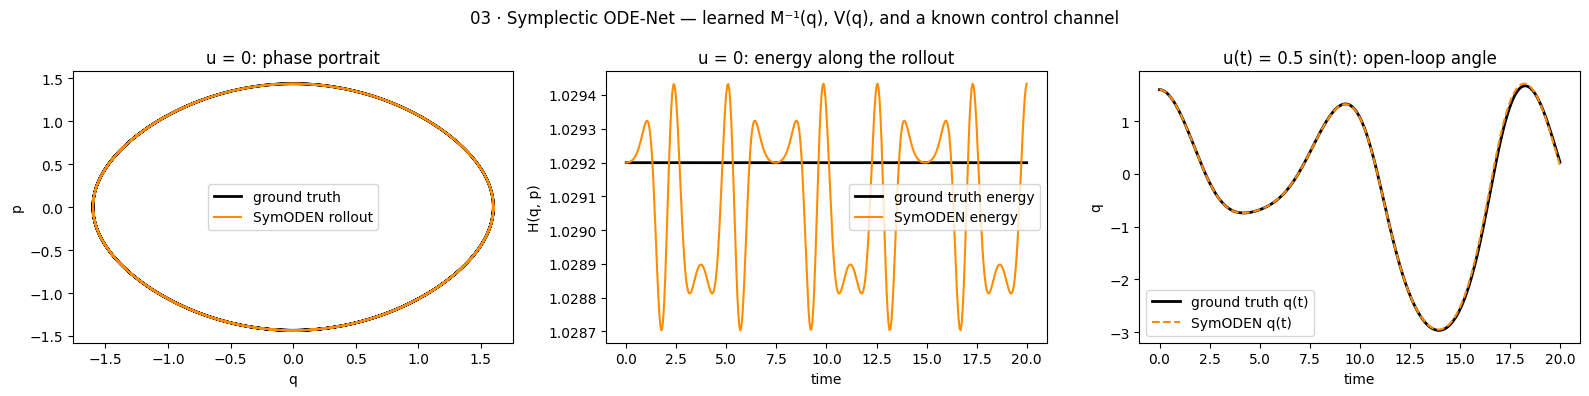

In [7]:
t = np.arange(len(true_traj)) * DT
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(true_traj[:, 0], true_traj[:, 1], label="ground truth", color="black", lw=2)
axes[0].plot(pred_traj[:, 0], pred_traj[:, 1], label="SymODEN rollout", color="darkorange", lw=1.5)
axes[0].set_xlabel("q"); axes[0].set_ylabel("p")
axes[0].set_title("u = 0: phase portrait")
axes[0].legend()

axes[1].plot(t, H_true, label="ground truth energy", color="black", lw=2)
axes[1].plot(t, H_pred, label="SymODEN energy", color="darkorange", lw=1.5)
axes[1].set_xlabel("time"); axes[1].set_ylabel("H(q, p)")
axes[1].set_title("u = 0: energy along the rollout")
axes[1].legend()

axes[2].plot(t, true_traj_u[:, 0], label="ground truth q(t)", color="black", lw=2)
axes[2].plot(t, pred_traj_u[:, 0], label="SymODEN q(t)", color="darkorange", lw=1.5, linestyle="--")
axes[2].set_xlabel("time"); axes[2].set_ylabel("q")
axes[2].set_title("u(t) = 0.5 sin(t): open-loop angle")
axes[2].legend()

fig.suptitle("03 · Symplectic ODE-Net — learned M⁻¹(q), V(q), and a known control channel")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_symoden_pendulum.png", dpi=130)
plt.show()

## Step 5 — Inspect what the network actually learned

Because `H_theta` is *decomposed* into `M_theta^{-1}(q)` and `V_theta(q)` rather
than being one opaque scalar, we can plot each against its true physical
counterpart (`M^{-1} = 1`, `V(q) = 1 - cos q` under this framework's unit
convention) -- this is the "interpretability" the paper advertises in Sec. 4.1.

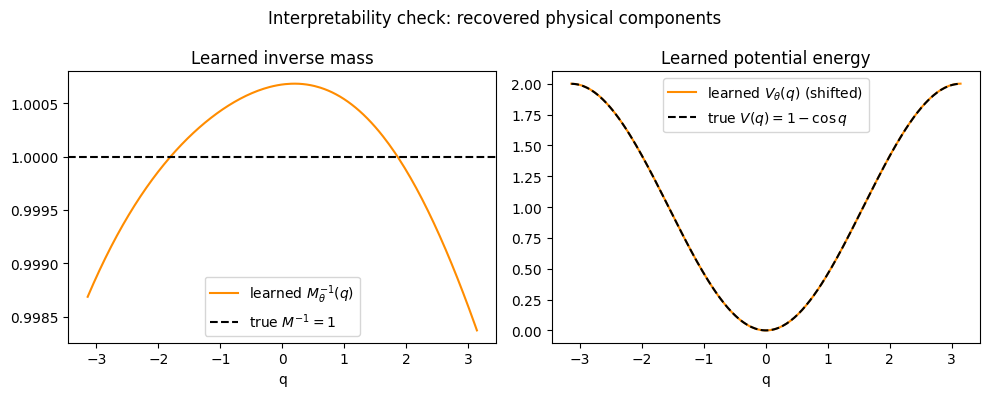

In [8]:
q_range = torch.linspace(-np.pi, np.pi, 200).unsqueeze(-1)
with torch.no_grad():
    Minv_learned = (nn.functional.softplus(symoden.Minv_net(q_range)) + symoden.eps).squeeze(-1)
    V_learned = symoden.V_net(q_range).squeeze(-1)
    V_learned = V_learned - V_learned.min()  # potentials are only defined up to a constant

V_true = 1 - torch.cos(q_range).squeeze(-1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(q_range.squeeze(-1), Minv_learned, label=r"learned $M_\theta^{-1}(q)$", color="darkorange")
axes[0].axhline(1.0, color="black", linestyle="--", label=r"true $M^{-1}=1$")
axes[0].set_xlabel("q"); axes[0].set_title("Learned inverse mass"); axes[0].legend()

axes[1].plot(q_range.squeeze(-1), V_learned, label=r"learned $V_\theta(q)$ (shifted)", color="darkorange")
axes[1].plot(q_range.squeeze(-1), V_true, label=r"true $V(q)=1-\cos q$", color="black", linestyle="--")
axes[1].set_xlabel("q"); axes[1].set_title("Learned potential energy"); axes[1].legend()

fig.suptitle("Interpretability check: recovered physical components")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_symoden_interpretability.png", dpi=130)
plt.show()

## Step 6 — Save the trained model and metrics

In [9]:
torch.save(symoden.state_dict(), RESULTS_DIR / "symoden_pendulum.pt")

result = {
    "model": "symoden_zhong2020",
    "system": "pendulum_controlled",
    "n_params": models.count_parameters(symoden),
    "final_train_mse": losses[-1],
    "rollout_trajectory_mse": traj_mse,       # u = 0 case, comparable to notebooks 00-02
    "max_abs_energy_drift": float(abs_drift.max()),
    "max_rel_energy_drift": float(rel_drift.max()),
    "open_loop_control_trajectory_mse": traj_mse_u,  # SymODEN-specific, not comparable across models
}
with open(RESULTS_DIR / "symoden_pendulum_metrics.json", "w") as f:
    json.dump(result, f, indent=2)
np.save(RESULTS_DIR / "symoden_pendulum_rollout.npy", pred_traj)

print(json.dumps(result, indent=2))

{
  "model": "symoden_zhong2020",
  "system": "pendulum_controlled",
  "n_params": 33794,
  "final_train_mse": 1.3900481690143351e-06,
  "rollout_trajectory_mse": 2.0238038663106515e-05,
  "max_abs_energy_drift": 0.0004964282322001967,
  "max_rel_energy_drift": 0.00048234401262327027,
  "open_loop_control_trajectory_mse": 0.0010652412815426594
}


## Notes for readers coming from a general-ML background

- This is the first notebook in the framework where the model takes an
  **exogenous input** in addition to the state -- structurally, this is the same
  idea as conditioning a generative model on side information, except here the
  conditioning variable enters *additively* into the (physically meaningful)
  `p_dot` channel rather than into an arbitrary hidden layer.
- Splitting `H` into `M_theta^{-1}(q)` and `V_theta(q)` instead of one opaque
  network is a deliberate loss of flexibility in exchange for interpretability --
  compare this to the difference between an end-to-end black-box classifier and a
  generalized additive model in classical statistics.
- The paper's ultimate motivation (Sec. 5, "energy-based control") is to use the
  *learned* `M_theta^{-1}` and `V_theta` inside a hand-derived nonlinear control
  law (e.g. energy-shaping swing-up control) instead of the unknown true ones --
  we do not implement a full closed-loop controller here to keep this notebook
  focused, but Step 5 shows the model has, in fact, recovered physically
  sensible `M^{-1}` and `V` functions, which is the prerequisite for that use case.
- `papers/02_Port_Hamiltonian_NN/` contains several direct extensions of this exact
  idea: `Dissipative SymODEN` (adds a damping/dissipation term to `p_dot`),
  `Stable Port-Hamiltonian Neural Networks` (adds a Lyapunov-stability guarantee),
  and `Port-Hamiltonian Neural Networks with Output Error Noise Models` (handles
  noisy measurements) -- all are structurally small deltas on top of the module
  defined in Step 2.